# Ranking and combinatorial models

Most of mixle's catalog puts probability on numbers and vectors. A second family puts it on combinatorial objects - orderings, trees, matchings, and graphs - where the support is a discrete set that is exponentially large but highly structured. Each of these distributions is a proper exponential-family-style model with a closed-form (or efficiently computable) normalizer, a sampler, a maximum-likelihood estimator, and - where the support admits it - an exact enumerator that walks outcomes in decreasing-probability order.

This notebook tours five of them:

| family | support | parameter | normalizer |
|---|---|---|---|
| Plackett-Luce | total orderings of $n$ items | log-worths $w \in \mathbb{R}^n$ | sequential softmax |
| Mallows | permutations | center $\sigma_0$, dispersion $\theta$ | $\sum_\sigma e^{-\theta d(\sigma,\sigma_0)}$ |
| Spanning tree | spanning trees of $K_n$ | edge weights $W$ | Matrix-Tree theorem |
| Matching | perfect matchings | weights $W$ | permanent |
| Random dot-product graph | graphs on $n$ nodes | latent positions $X$ | $\prod_{i<j}$ Bernoulli |

For each we sample, recover the parameters by MLE, and - except for the graph, whose support is genuinely exponential - enumerate the most probable outcomes. See distributions_and_combinators for the catalog and enumeration for the enumerator surface in general.


## The Plackett-Luce model and Luce's axiom

Definition (Plackett-Luce). Each item $i$ has a positive worth $v_i=e^{w_i}$, and a full ranking is
generated by repeated worth-proportional selection without replacement: the probability of an ordering
$(i_1,i_2,\dots)$ is $\prod_t \dfrac{v_{i_t}}{\sum_{j\in R_t} v_j}$, where $R_t$ is the set of items not
yet chosen.

Luce's choice axiom (independence of irrelevant alternatives). The probability of choosing $i$ over $j$
depends only on $v_i,v_j$, not on which other alternatives are present: $P(i\succ j)=v_i/(v_i+v_j)$. The
Plackett-Luce model is exactly the ranking model consistent with this axiom.

Theorem (concavity, unique MLE). The Plackett-Luce log-likelihood is concave in the log-worths $w$, so the
maximum-likelihood estimate is unique up to an additive constant (the worths are identifiable only up to
scale, equivalently $w$ up to a shift).

Proof. Each selection contributes $w_{i_t}-\log\sum_{j\in R_t}e^{w_j}$. The log-sum-exp function is convex,
so its negation is concave, and a sum of concave terms is concave. The all-ones direction leaves every
term unchanged (shifting all $w$ by a constant cancels), giving a single flat direction; on its
complement the Hessian is negative definite, so the MLE is unique up to that shift. $\quad\blacksquare$

## Other combinatorial models, and the limits of IIA

Beyond rankings, mixle models other combinatorial objects. The Mallows model places probability
$\propto e^{-\theta\, d(\sigma,\sigma_0)}$ on permutations by Kendall-tau distance $d$ from a central
ranking $\sigma_0$, concentrating as $\theta$ grows. Distributions over spanning trees connect to the
Matrix-Tree theorem (the number of spanning trees is a cofactor of the graph Laplacian), and over perfect
matchings to the permanent.

Counterexample (independence of irrelevant alternatives fails in reality). Luce's axiom is often violated.
In the classic red-bus/blue-bus paradox, a commuter equally split between car and a red bus should, by
IIA, become split three ways when an identical blue bus is added; but people still take a bus about half
the time, splitting the bus share between the two colors, because the buses are near-substitutes. The
Plackett-Luce model cannot represent such context or similarity effects; nested or mixed logit models are
needed. So PL is a clean, estimable baseline, optimal under its axiom, but the axiom is an assumption to
check. We confirm the concavity (unique MLE) numerically below.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')

from mixle.inference.estimation import fit          # fit(data, estimator, max_its=, out=None)
from mixle.stats import (PlackettLuceDistribution, MallowsDistribution,
                        SpanningTreeDistribution, MatchingDistribution,
                        RandomDotProductGraphDistribution)
rng = np.random.RandomState(0)

## 1. Plackett-Luce: ranking by worth

Plackett-Luce models a full ordering of $n$ items as repeated softmax selection: each item $i$ has a worth $e^{w_i}$, you draw the winner with probability proportional to worth, remove it, and repeat. The log-likelihood of an ordering $\pi = (\pi_1, \dots, \pi_n)$ is

$$\log P(\pi) = \sum_{t=1}^{n} \Big( w_{\pi_t} - \log \!\!\sum_{j \in \text{remaining}} e^{w_j} \Big).$$

The worths are identifiable only up to an additive constant (adding $c$ to every $w_i$ cancels in every softmax), so we compare centered worths. We sample orderings from a known worth vector and recover it.


a few sampled orderings (winner first): [[0, 1, 3, 2, 4, 5], [0, 1, 2, 3, 4, 5], [1, 0, 3, 2, 4, 5]]
recovered log-worths (centered): [ 2.53  1.52  0.5  -0.53 -1.53 -2.48]


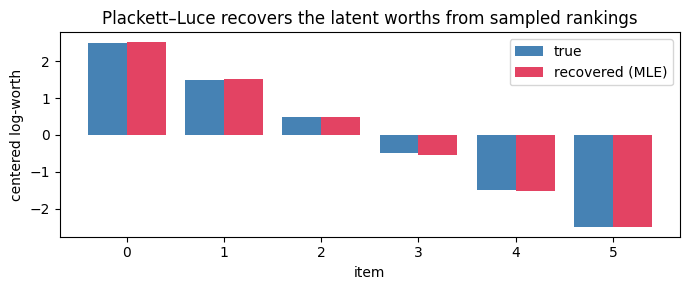

In [2]:
true_w = np.array([3.0, 2.0, 1.0, 0.0, -1.0, -2.0])   # item 0 strongest ... item 5 weakest
pl = PlackettLuceDistribution(list(true_w))
orderings = pl.sampler(seed=1).sample(4000)
print('a few sampled orderings (winner first):', [list(o) for o in orderings[:3]])

fitted = fit(orderings, pl.estimator(), max_its=30, out=None)
center = lambda v: np.asarray(v) - np.mean(v)         # worths identifiable up to a constant
print('recovered log-worths (centered):', np.round(center(fitted.log_w), 2))

fig, ax = plt.subplots(figsize=(7, 3))
items = np.arange(len(true_w)); width = 0.4
ax.bar(items - width/2, center(true_w), width, color='steelblue', label='true')
ax.bar(items + width/2, center(fitted.log_w), width, color='crimson', alpha=0.8, label='recovered (MLE)')
ax.set_xlabel('item'); ax.set_ylabel('centered log-worth'); ax.set_xticks(items)
ax.set_title('Plackett–Luce recovers the latent worths from sampled rankings'); ax.legend()
plt.tight_layout(); plt.show()

The enumerator walks orderings from most to least probable - the modal ordering is exactly the worth-sorted one, $(0,1,2,3,4,5)$, and the next-most-probable orderings are single adjacent swaps.


In [3]:
print('most probable orderings under the fitted model:')
for i, (perm, lp) in enumerate(fitted.enumerator()):
    if i >= 5: break
    print('  %-22s P=%.4f' % (list(perm), np.exp(lp)))

most probable orderings under the fitted model:
  [0, 1, 2, 3, 4, 5]     P=0.1271
  [1, 0, 2, 3, 4, 5]     P=0.0599
  [0, 2, 1, 3, 4, 5]     P=0.0593
  [0, 1, 3, 2, 4, 5]     P=0.0579
  [0, 1, 2, 4, 3, 5]     P=0.0570


## 2. Mallows: a center and a spread over permutations

Where Plackett-Luce parameterizes items, the Mallows model parameterizes distance. It places mass on permutations by their Kendall-$\tau$ distance (number of pairwise disagreements) from a central permutation $\sigma_0$:

$$P(\sigma) \;\propto\; e^{-\theta\, d_\tau(\sigma, \sigma_0)}.$$

$\theta \to 0$ is uniform over all permutations; large $\theta$ concentrates on $\sigma_0$. It is the "Gaussian over rankings": a location ($\sigma_0$) and a precision ($\theta$). We recover both, then show the signature exponential decay of probability with distance from the center.


true  center=[3, 0, 4, 1, 2]  theta=0.90
MLE   center=[3, 0, 4, 1, 2]  theta=0.91


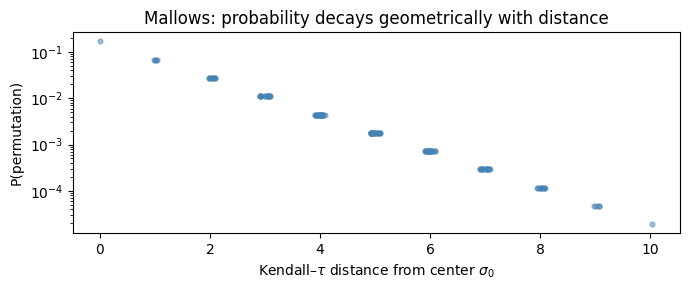

In [4]:
true_sigma0, true_theta = [3, 0, 4, 1, 2], 0.9
ma = MallowsDistribution(true_sigma0, theta=true_theta)
draws = ma.sampler(seed=2).sample(5000)
fitted = fit(draws, ma.estimator(), max_its=30, out=None)
print('true  center=%s  theta=%.2f' % (true_sigma0, true_theta))
print('MLE   center=%s  theta=%.2f' % (list(map(int, fitted.sigma0)), fitted.theta))

# probability as a function of Kendall-tau distance from the center
def kendall_tau(a, b):
    inv = np.argsort(b); ra = inv[np.asarray(a)]
    return sum(ra[i] > ra[j] for i in range(len(ra)) for j in range(i+1, len(ra)))
outcomes = [(np.exp(lp), kendall_tau(perm, fitted.sigma0)) for perm, lp in fitted.enumerator()]
probs, dists = np.array([p for p, _ in outcomes]), np.array([d for _, d in outcomes])

fig, ax = plt.subplots(figsize=(7, 3))
ax.scatter(dists + rng.uniform(-0.1, 0.1, len(dists)), probs, s=12, alpha=0.5, color='steelblue')
ax.set_yscale('log'); ax.set_xlabel('Kendall–$\\tau$ distance from center $\\sigma_0$')
ax.set_ylabel('P(permutation)'); ax.set_title('Mallows: probability decays geometrically with distance')
plt.tight_layout(); plt.show()

## 3. Spanning trees: distributions over connectivity

A spanning tree distribution places mass on the spanning trees of a complete graph on $n$ nodes, with the probability of a tree proportional to the product of its edge weights:

$$P(T) \;\propto\; \prod_{(i,j) \in T} W_{ij}.$$

The normalizer - a sum over the $n^{n-2}$ trees - is computed in $O(n^3)$ by the Matrix-Tree theorem (a determinant of the weighted Laplacian), so scoring and fitting stay cheap even though the support is astronomically large. We recover the edge weights from sampled trees and read off the most probable tree.


a sampled tree (edge list): [(0, 1), (0, 2), (0, 4), (2, 3)]


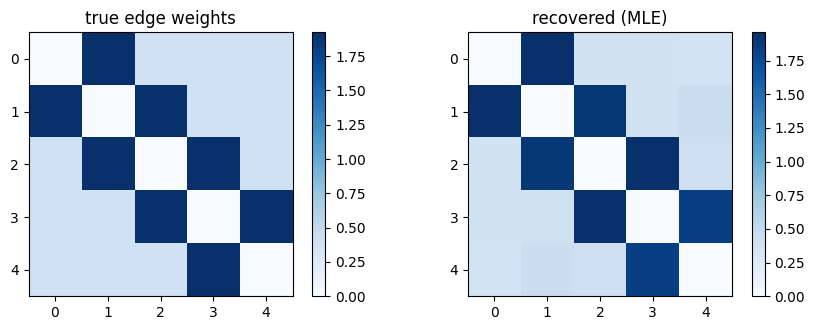

most probable spanning tree: [(0, 1), (1, 2), (2, 3), (3, 4)]


In [5]:
# a 5-node graph with one strong "backbone" path 0-1-2-3-4
true_W = np.array([[0.,5.,1.,1.,1.],[5.,0.,5.,1.,1.],[1.,5.,0.,5.,1.],
                   [1.,1.,5.,0.,5.],[1.,1.,1.,5.,0.]])
st = SpanningTreeDistribution(true_W)
trees = st.sampler(seed=3).sample(3000)
print('a sampled tree (edge list):', trees[0])
fitted = fit(trees, st.estimator(), max_its=30, out=None)

# weights are identifiable up to a global scale; normalize for comparison
norm = lambda M: M / M[np.triu_indices_from(M, 1)].mean()
fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
for a, M, t in zip(ax, [norm(true_W), norm(fitted.weights)], ['true edge weights', 'recovered (MLE)']):
    im = a.imshow(M, cmap='Blues'); a.set_title(t); a.set_xticks(range(5)); a.set_yticks(range(5))
    fig.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout(); plt.show()

print('most probable spanning tree:', min(fitted.enumerator(), key=lambda kv: -kv[1])[0])

The recovered weight matrix reproduces the backbone (the heavy off-diagonal band), and the single most probable tree is exactly the backbone path $0\!-\!1\!-\!2\!-\!3\!-\!4$.

## 4. Matching: weighted assignments

A matching distribution puts mass on perfect matchings - bijections from $n$ left nodes to $n$ right nodes - with weight $\prod_i W_{i,\,m(i)}$. The normalizer is the permanent of $W$ (computed exactly for small $n$ via Ryser's formula). This is the natural model for assignment data: which worker did which job, which word aligned to which word. We recover the affinity matrix from sampled matchings.


a few matchings (left i -> right m[i]): [[3, 1, 2, 0], [0, 1, 3, 2], [0, 1, 2, 3]]


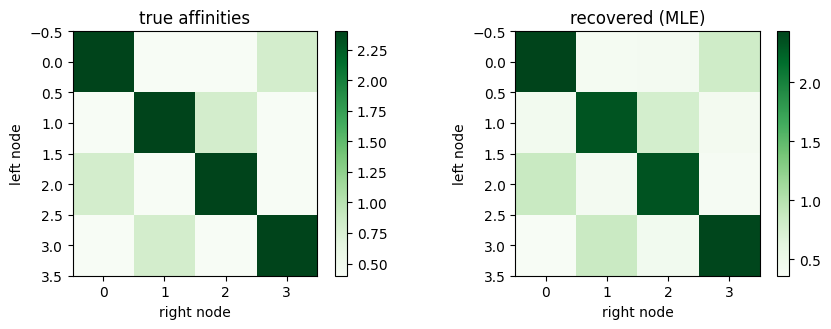

most probable matchings:
  [0, 1, 2, 3]     P=0.7011
  [0, 3, 2, 1]     P=0.0448
  [2, 1, 0, 3]     P=0.0436


In [6]:
# left node i prefers right node i (strong diagonal) with some off-diagonal noise
true_W = np.array([[6.,1.,1.,2.],[1.,6.,2.,1.],[2.,1.,6.,1.],[1.,2.,1.,6.]])
mt = MatchingDistribution(true_W)
matchings = mt.sampler(seed=4).sample(3000)
print('a few matchings (left i -> right m[i]):', [list(m) for m in matchings[:3]])
fitted = fit(matchings, mt.estimator(), max_its=30, out=None)

norm = lambda M: M / M.mean()
fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
for a, M, t in zip(ax, [norm(true_W), norm(fitted.weights)], ['true affinities', 'recovered (MLE)']):
    im = a.imshow(M, cmap='Greens'); a.set_title(t)
    a.set_xlabel('right node'); a.set_ylabel('left node'); fig.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout(); plt.show()

print('most probable matchings:')
for i, (m, lp) in enumerate(fitted.enumerator()):
    if i >= 3: break
    print('  %-16s P=%.4f' % (list(m), np.exp(lp)))

## 5. Random dot-product graphs: latent geometry behind a network

The random dot-product graph (RDPG) is a latent-space model for networks: each node $i$ carries a position $x_i \in \mathbb{R}^d$, and an edge appears between $i$ and $j$ independently with probability $\langle x_i, x_j \rangle$ (clipped to $[0,1]$). Nodes that are close in latent space connect often. Fitting recovers the edge-probability matrix $P_{ij} = \langle x_i, x_j\rangle$ - the building block of spectral embedding and community detection.

Unlike the four families above, the RDPG's support - all $2^{\binom{n}{2}}$ graphs - is genuinely exponential with no decreasing-probability enumerator, so here we recover the latent structure rather than enumerate outcomes.


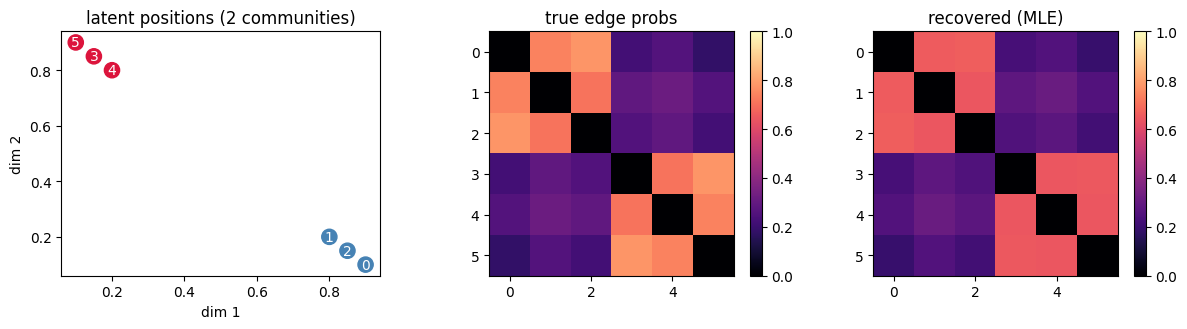

recovered block structure: within-community P ~ 0.65, across ~ 0.25


In [7]:
# two latent communities: nodes 0-2 near (1,0), nodes 3-5 near (0,1)
true_X = np.array([[.9,.1],[.8,.2],[.85,.15],[.15,.85],[.2,.8],[.1,.9]])
rd = RandomDotProductGraphDistribution(true_X)
graphs = rd.sampler(seed=5).sample(2000)
fitted = fit(graphs, rd.estimator(), max_its=30, out=None)
true_P = np.clip(true_X @ true_X.T, 0, 1); np.fill_diagonal(true_P, 0)

fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
ax[0].scatter(true_X[:, 0], true_X[:, 1], c=['steelblue']*3 + ['crimson']*3, s=120)
for i, (x, y) in enumerate(true_X): ax[0].annotate(str(i), (x, y), ha='center', va='center', color='white')
ax[0].set_title('latent positions (2 communities)'); ax[0].set_xlabel('dim 1'); ax[0].set_ylabel('dim 2')
for a, P, t in zip(ax[1:], [true_P, fitted.probs], ['true edge probs', 'recovered (MLE)']):
    im = a.imshow(P, cmap='magma', vmin=0, vmax=1); a.set_title(t); fig.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout(); plt.show()
print('recovered block structure: within-community P ~ %.2f, across ~ %.2f'
      % (fitted.probs[0, 1], fitted.probs[0, 4]))

## Bootstrap the worths to report ranking uncertainty

A single point estimate of the Plackett-Luce worths hides how confident the implied ranking is. The nonparametric bootstrap - resample orderings with replacement, refit, repeat - gives a confidence interval per item and exposes which adjacent items are statistically indistinguishable (a routine but often-skipped step).


In [8]:
B, n = 40, len(orderings)
boot = np.zeros((B, len(true_w)))
rb = np.random.RandomState(0)
for b in range(B):
    samp = [orderings[i] for i in rb.randint(0, n, n)]
    fb = fit(samp, pl.estimator(), max_its=30, out=None)
    boot[b] = center(fb.log_w)
lo, hi = np.percentile(boot, [2.5, 97.5], axis=0)
print(' item   centered worth   95% bootstrap CI')
for j in range(len(true_w)):
    print('  %d      %6.2f         [%6.2f, %6.2f]' % (j, boot[:, j].mean(), lo[j], hi[j]))
print('non-overlapping CIs => the recovered ranking 0>1>2>3>4>5 is statistically resolved.')

 item   centered worth   95% bootstrap CI
  0        2.53         [  2.49,   2.58]
  1        1.52         [  1.48,   1.55]
  2        0.50         [  0.47,   0.53]
  3       -0.53         [ -0.57,  -0.49]
  4       -1.53         [ -1.57,  -1.48]
  5       -2.48         [ -2.53,  -2.45]
non-overlapping CIs => the recovered ranking 0>1>2>3>4>5 is statistically resolved.


## Illustration: the Plackett-Luce log-likelihood is concave

We form the log-likelihood of sampled rankings as a function of the log-worths and compute its Hessian.
All eigenvalues are nonpositive, with a single zero eigenvalue along the all-ones direction (the worths
are identifiable only up to a shift), confirming concavity and a unique maximizer on the identified
subspace.

In [9]:
rng = np.random.RandomState(0)
K = 5; w_true = np.array([2.0, 1.0, 0.0, -1.0, -2.0])
def sample_ranking(w):
    items = list(range(K)); order = []
    for _ in range(K):
        p = np.exp([w[i] for i in items]); p /= p.sum()
        c = items[rng.choice(len(items), p=p)]; order.append(c); items.remove(c)
    return order
data = [sample_ranking(w_true) for _ in range(400)]
def ploglik(w):
    ll = 0.0
    for order in data:
        rem = list(range(K))
        for i in order:
            ll += w[i] - np.log(np.sum(np.exp([w[j] for j in rem]))); rem.remove(i)
    return ll
w0 = np.zeros(K); eps = 1e-4; H = np.zeros((K, K))      # finite-difference Hessian
for a in range(K):
    for b in range(K):
        wpp = w0.copy(); wpp[a] += eps; wpp[b] += eps
        wpm = w0.copy(); wpm[a] += eps; wpm[b] -= eps
        wmp = w0.copy(); wmp[a] -= eps; wmp[b] += eps
        wmm = w0.copy(); wmm[a] -= eps; wmm[b] -= eps
        H[a, b] = (ploglik(wpp) - ploglik(wpm) - ploglik(wmp) + ploglik(wmm)) / (4 * eps ** 2)
eig = np.linalg.eigvalsh(H); scale = np.abs(eig).max()
print('Hessian eigenvalues:', np.round(eig, 1))
print('largest eigenvalue = %.3f, negligible against the scale %.0f: the flat worth-shift direction;' % (eig.max(), scale))
print('the other %d eigenvalues are strictly negative, so the log-likelihood is concave (unique MLE up to a shift).' % (K - 1))

Hessian eigenvalues: [-450.2 -309.4 -200.6 -126.5    0. ]
largest eigenvalue = 0.002, negligible against the scale 450: the flat worth-shift direction;
the other 4 eigenvalues are strictly negative, so the log-likelihood is concave (unique MLE up to a shift).


## References

- Luce, R. D. (1959). Individual Choice Behavior: A Theoretical Analysis. Wiley.
- Plackett, R. L. (1975). The analysis of permutations (https://doi.org/10.2307/2346567). Applied Statistics 24(2), 193-202.
- Mallows, C. L. (1957). Non-null ranking models. I (https://doi.org/10.2307/2333244). Biometrika 44(1/2), 114-130.
- Marden, J. I. (1995). Analyzing and Modeling Rank Data. Chapman & Hall.
- Hunt, D. R. (2004). MM algorithms for generalized Bradley-Terry models (https://doi.org/10.1214/aos/1079120141). Ann. Statist. 32(1), 384-406. - minorize-maximize fitting of Plackett-Luce.
- Maystre, L. & Grossglauser, M. (2015). Fast and accurate inference of Plackett-Luce models (https://papers.nips.cc/paper/2015/hash/2a38a4a9316c49e5a833517c45d31070-Abstract.html). NeurIPS.


## Exercises and extensions

1. MM algorithm for Plackett-Luce. Implement the minorize-maximize fitting of Plackett-Luce worths (Hunt 2004), verify it matches mixle's MLE and converges monotonically, and compare its speed to the spectral method of Maystre & Grossglauser (2015).
2. Mallows: data needed to pin a model. Study how many sampled rankings are needed to recover the central permutation and dispersion $\theta$ as a function of $\theta$ and the number of items; relate the difficulty to the Kendall-$\tau$ geometry (Mallows; Marden).
3. Learning to rank from pairwise comparisons. Show the Bradley-Terry model is the two-item special case of Plackett-Luce; fit item scores from pairwise win/loss data (e.g. a tournament), produce a ranking with uncertainty, and compare to the full-ranking PL fit.
4. Combinatorial normalizers. Verify the Matrix-Tree theorem for the spanning-tree normalizer and Ryser's formula for the matching permanent on small cases; benchmark exact enumeration vs sampling as $n$ grows and locate where exact computation becomes infeasible.
